In [ ]:
#pip install torch
# %pip install genai
# %pip install google-genai
# %pip install langchain_google_genai

Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
import torch
import torch.nn as nn 
import torch.optim as op 
import matplotlib.pyplot as plt

In [21]:
# For reproducibility
torch.manual_seed(42)
# constants for the linear function y=ax+b
a= 3.0
b=2.0
# Generate random inputs [ 100 points for training data (x between  0 & 10)]
x_train = torch.rand(100,1)*10

# y=ax+b  with some noise
# noise is adjusted by multiplying with 0.5
y_train= a*x_train + b + torch.rand(100,1)*0.5

In [25]:
### define neural network
class NeuralNetworkModule(nn.Module):
    def __init__(self):
        super(NeuralNetworkModule,self).__init__()
        self.hidden1=nn.Linear(1,10)
        self.hidden2=nn.Linear(10,10)
        self.output=nn.Linear(10,1)

    def forward(self,x):
        x=torch.relu(self.hidden1(x))
        x=torch.relu(self.hidden2(x))
        x=self.output(x)
        return x
    
    
model=NeuralNetworkModule()

In [26]:
# Mean Square Error

criterion = nn.MSELoss()
optimizer= op.Adam(model.parameters(),lr=0.01)

In [29]:
data= 1000

for d in range(data):
    model.train()
    output=model(x_train)
    loss=criterion(output,y_train)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if(d+1) % 100 ==0:
        print(f'Epoch [{d+1}/{data}],Loss :{loss.item(): .4f} ')

Epoch [100/1000],Loss : 0.0186 
Epoch [200/1000],Loss : 0.0186 
Epoch [300/1000],Loss : 0.0186 
Epoch [400/1000],Loss : 0.0186 
Epoch [500/1000],Loss : 0.0186 
Epoch [600/1000],Loss : 0.0186 
Epoch [700/1000],Loss : 0.0186 
Epoch [800/1000],Loss : 0.0186 
Epoch [900/1000],Loss : 0.0186 
Epoch [1000/1000],Loss : 0.0186 


In [36]:
x=10.0
print('Actual Value ',(a*x+b))
tensor = torch.tensor([[x]], dtype=torch.float32)

with torch.no_grad():
    predict = model(tensor).detach().numpy()

print("predicated :",predict[0:][0])

Actual Value  32.0
predicated : [32.239716]


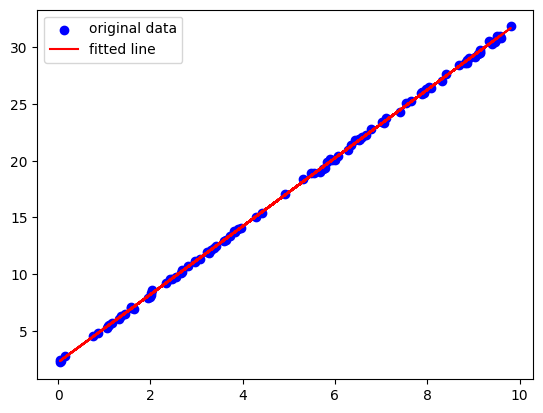

In [40]:
# plot 
model.eval()

with torch.no_grad():
    predict = model(x_train).detach().numpy()

plt.scatter(x_train.numpy(), y_train.numpy(), color='blue', label='original data')
plt.plot(x_train.numpy(), predict, color='red', label='fitted line')

plt.legend()
plt.show()
